In [1]:
from trendspy import Trends
import pandas as pd
import matplotlib.pyplot as plt

tr = Trends()
tendencias = tr.interest_over_time(
    ["CPI", "inflation report"],
    timeframe="2023-01-01 2026-08-06",
    geo="US"
)
print(tendencias.head())
print(tendencias.shape)

            CPI  inflation report  isPartial
time [UTC]                                  
2023-01-01   15                 1      False
2023-01-08   68                 6      False
2023-01-15   17                 1      False
2023-01-22   16                 1      False
2023-01-29   18                 1      False
(188, 3)


In [2]:
tendencias["atencao_bruta"] = tendencias[["CPI", "inflation report"]].mean(axis=1)
print(tendencias[["atencao_bruta"]].head())

            atencao_bruta
time [UTC]               
2023-01-01            8.0
2023-01-08           37.0
2023-01-15            9.0
2023-01-22            8.5
2023-01-29            9.5


In [3]:
tendencias = tendencias.reset_index().rename(columns={"time [UTC]": "data"})
tendencias["data"] = tendencias["data"].astype("datetime64[ns]")
print(tendencias.columns.tolist())
print(tendencias[["data", "atencao_bruta"]].head())

['data', 'CPI', 'inflation report', 'isPartial', 'atencao_bruta']
        data  atencao_bruta
0 2023-01-01            8.0
1 2023-01-08           37.0
2 2023-01-15            9.0
3 2023-01-22            8.5
4 2023-01-29            9.5


In [4]:
eventos = pd.read_csv("../data/eventos.csv")
eventos["data"] = pd.to_datetime(eventos["data"]).astype("datetime64[ns]")

In [5]:
tendencias = tendencias.sort_values("data")
eventos = eventos.sort_values("data")

eventos_ian = pd.merge_asof(eventos, tendencias[["data", "atencao_bruta"]], on="data", direction="backward")
print(eventos_ian[["data", "surpresa_zscore", "atencao_bruta"]])

         data  surpresa_zscore  atencao_bruta
0  2023-03-14         0.000000           23.0
1  2023-04-12        -1.007506           28.0
2  2023-05-10         0.000000           22.0
3  2023-06-13        -1.007506           20.0
4  2023-07-12        -1.007506           23.0
5  2023-08-10         0.000000           23.0
6  2023-09-13         0.000000           19.5
7  2023-10-12         1.007506           18.0
8  2023-11-14        -1.007506           20.5
9  2023-12-12         1.007506           16.0
10 2024-01-11         1.007506           16.5
11 2024-02-13         1.007506           25.0
12 2024-03-12         0.000000           20.5
13 2024-04-10         1.007506           28.0
14 2024-05-15        -1.007506           25.0
15 2024-06-12        -1.007506           19.0
16 2024-07-11        -2.015012           22.0
17 2024-08-14         0.000000           23.5
18 2024-09-11         0.000000           18.5
19 2024-10-10         1.007506           15.0
20 2024-11-13         0.000000    

In [6]:
minimo = eventos_ian["atencao_bruta"].min()
maximo = eventos_ian["atencao_bruta"].max()

eventos_ian["IAN"] = (eventos_ian["atencao_bruta"] - minimo) / (maximo - minimo)
print(eventos_ian[["data", "surpresa_zscore", "IAN"]])

         data  surpresa_zscore       IAN
0  2023-03-14         0.000000  0.200000
1  2023-04-12        -1.007506  0.311111
2  2023-05-10         0.000000  0.177778
3  2023-06-13        -1.007506  0.133333
4  2023-07-12        -1.007506  0.200000
5  2023-08-10         0.000000  0.200000
6  2023-09-13         0.000000  0.122222
7  2023-10-12         1.007506  0.088889
8  2023-11-14        -1.007506  0.144444
9  2023-12-12         1.007506  0.044444
10 2024-01-11         1.007506  0.055556
11 2024-02-13         1.007506  0.244444
12 2024-03-12         0.000000  0.144444
13 2024-04-10         1.007506  0.311111
14 2024-05-15        -1.007506  0.244444
15 2024-06-12        -1.007506  0.111111
16 2024-07-11        -2.015012  0.177778
17 2024-08-14         0.000000  0.211111
18 2024-09-11         0.000000  0.100000
19 2024-10-10         1.007506  0.022222
20 2024-11-13         0.000000  0.000000
21 2024-12-11         0.000000  0.011111
22 2025-01-15         0.000000  0.144444
23 2025-02-12   

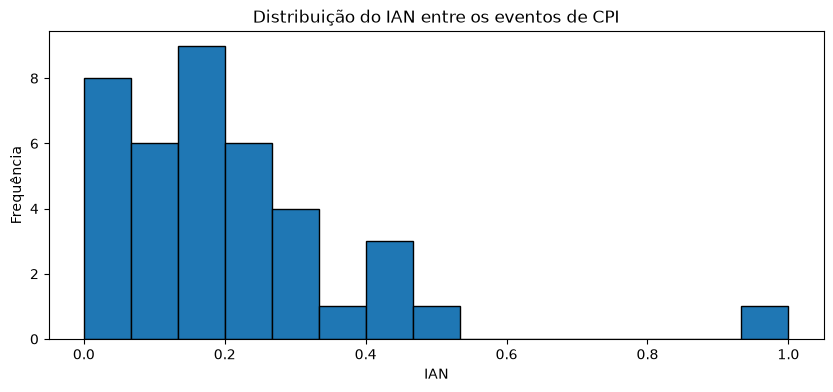

In [7]:
plt.figure(figsize=(10, 4))
plt.hist(eventos_ian["IAN"], bins=15, edgecolor="black")
plt.xlabel("IAN")
plt.ylabel("Frequência")
plt.title("Distribuição do IAN entre os eventos de CPI")
plt.show()

In [8]:
eventos_ian.to_csv("../data/eventos_com_ian.csv", index=False)

Outlier no IAN (evento de 10/06/2026)

A normalização Min-Max do IAN é sensível a valores extremos. O evento de
10/06/2026 (CPI de maio/2026) apresentou atenção de busca bem acima dos
demais, coincidindo com um período de convergência de notícias econômicas
relevantes (CPI de maio veio acima do esperado, reunião do Fed com tom
hawkish sob a nova liderança de Kevin Warsh, tensões geopolíticas EUA-Irã
afetando preços de energia). Optou-se por manter a normalização padrão
(Min-Max sobre o range completo), por ser fiel à fórmula especificada e
por o outlier representar um evento real, não ruído de dado.